###  Cargar y Explorar el Dataset

In [4]:
import pandas as pd

# Cargar dataset
df = pd.read_csv(r"D:\Universidad\8 - Octavo\Business Intelligence\Proyecto Segundo Bimestre\Dataset\tipvos_merged_all.csv")

# Vista general
print(df.shape)
print(df.info())
print(df.describe(include='all'))
df.head()


(10219, 20)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10219 entries, 0 to 10218
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   transaction_id    10219 non-null  object 
 1   customer_id       10219 non-null  object 
 2   product_id        10219 non-null  object 
 3   quantity          10219 non-null  int64  
 4   transaction_date  10219 non-null  object 
 5   product_name      10219 non-null  object 
 6   category          10219 non-null  object 
 7   price             10219 non-null  float64
 8   stock             10219 non-null  int64  
 9   name              10219 non-null  object 
 10  email             10219 non-null  object 
 11  age               10219 non-null  int64  
 12  gender            10219 non-null  object 
 13  region            10219 non-null  object 
 14  signup_date       10219 non-null  object 
 15  visit_id          10173 non-null  object 
 16  visit_date        10173 non-

,transaction_id,customer_id,product_id,quantity,transaction_date,product_name,category,price,stock,name,email,age,gender,region,signup_date,visit_id,visit_date,pages_viewed,device,duration_seconds
0,TX00001,CUST0159,PROD064,2,2025-02-23,Decision,Home,409.45,48,James Rodriguez,jacksonelizabeth@hotmail.com,56,Female,North,2023-09-15,VISIT00472,2024-08-01,1.0,Tablet,149.0
1,TX00001,CUST0159,PROD064,2,2025-02-23,Decision,Home,409.45,48,James Rodriguez,jacksonelizabeth@hotmail.com,56,Female,North,2023-09-15,VISIT00743,2024-07-19,1.0,Desktop,1132.0
2,TX00001,CUST0159,PROD064,2,2025-02-23,Decision,Home,409.45,48,James Rodriguez,jacksonelizabeth@hotmail.com,56,Female,North,2023-09-15,VISIT00939,2025-06-26,4.0,Desktop,953.0
3,TX00001,CUST0159,PROD064,2,2025-02-23,Decision,Home,409.45,48,James Rodriguez,jacksonelizabeth@hotmail.com,56,Female,North,2023-09-15,VISIT01013,2025-01-14,10.0,Mobile,632.0
4,TX00001,CUST0159,PROD064,2,2025-02-23,Decision,Home,409.45,48,James Rodriguez,jacksonelizabeth@hotmail.com,56,Female,North,2023-09-15,VISIT01135,2024-10-07,7.0,Desktop,546.0


### Limpieza

In [5]:
df['transaction_date'] = pd.to_datetime(df['transaction_date'])
df['signup_date'] = pd.to_datetime(df['signup_date'])
df['visit_date'] = pd.to_datetime(df['visit_date'], errors='coerce')  # Maneja valores nulos


In [ ]:
print("Categorías únicas por columna:\n", df.nunique())
print("Valores nulos:\n", df.isnull().sum())

Categorías únicas por columna:
 transaction_id      2000
customer_id          298
product_id           100
quantity               4
transaction_date     686
product_name          93
category               6
price                100
stock                 86
name                 298
email                298
age                   51
gender                 3
region                 4
signup_date          265
visit_id            1493
visit_date           360
pages_viewed          14
device                 3
duration_seconds     858
dtype: int64
Valores nulos:
 transaction_id       0
customer_id          0
product_id           0
quantity             0
transaction_date     0
product_name         0
category             0
price                0
stock                0
name                 0
email                0
age                  0
gender               0
region               0
signup_date          0
visit_id            46
visit_date          46
pages_viewed        46
device              46
du

In [ ]:
##Estadisticas por categoria
df.groupby('category')['price'].describe()

,count,mean,std,min,25%,50%,75%,max
category,,,,,,,,
Beauty,1682.0,250.674946,129.412078,55.38,132.66,256.27,373.99,493.33
Books,1688.0,211.521214,123.828727,23.16,122.43,208.15,258.28,445.81
Clothing,2024.0,198.318819,123.835114,58.05,97.59,138.28,268.63,495.03
Electronics,1760.0,203.224227,116.066750,44.72,81.41,147.87,299.84,416.16
Home,1816.0,259.176977,150.395148,14.94,146.12,264.63,409.45,484.89
Toys,1249.0,273.562610,123.131203,60.46,181.27,268.40,341.16,491.28


In [ ]:

df['revenue'] = df['quantity'] * df['price']
df.groupby('region')['revenue'].mean()

region
East     569.543102
North    596.323662
South    557.602550
West     596.325575
Name: revenue, dtype: float64

### Visualizacion

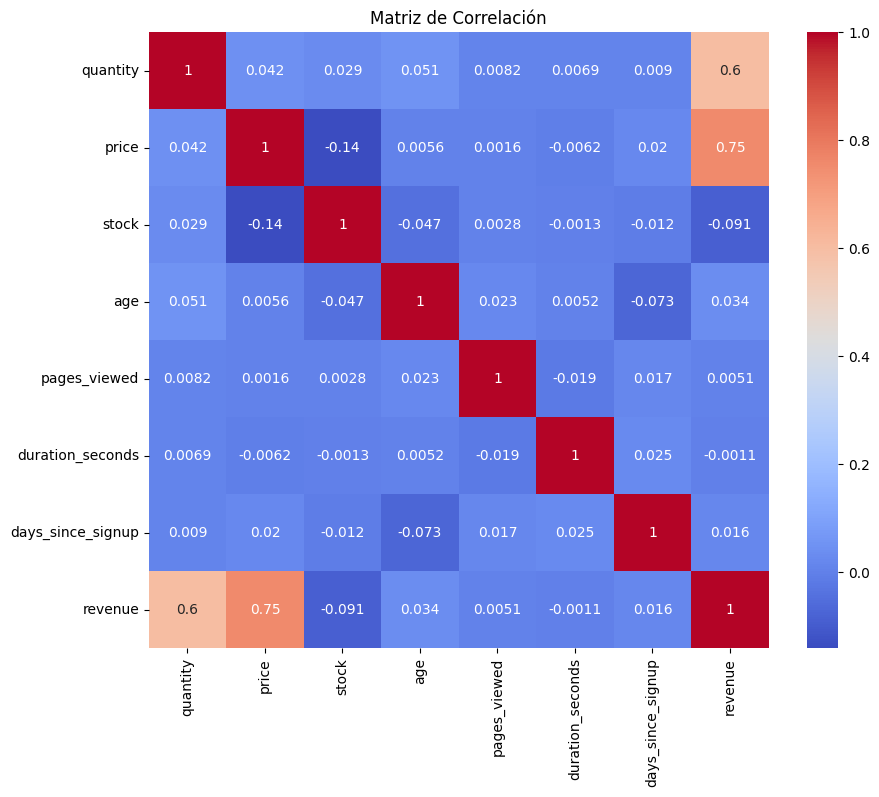

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

# Generar nuevas columnas primero
df['revenue'] = df['quantity'] * df['price']
df['days_since_signup'] = (df['transaction_date'] - df['signup_date']).dt.days

# Correlación
correlation_matrix = df[['quantity', 'price', 'stock', 'age', 'pages_viewed',
                         'duration_seconds', 'days_since_signup', 'revenue']].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Matriz de Correlación')
plt.show()


In [14]:
# Segmentación etaria
df['customer_age_group'] = pd.cut(df['age'], bins=[17, 25, 35, 45, 55, 70],
                                  labels=['18-25', '26-35', '36-45', '46-55', '56-70'])

# Valor total del producto en stock
df['product_total_value'] = df['price'] * df['stock']


In [19]:
%pip install scikit-learn


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 25.1.1
[notice] To update, run: C:\Users\steve\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [21]:
from sklearn.feature_selection import SelectKBest, f_regression
# Selección simple para variable objetivo 'revenue'
from sklearn.impute import SimpleImputer

# Handle missing values by imputing with the mean
imputer = SimpleImputer(strategy='mean')
X_imputed = imputer.fit_transform(df[['quantity', 'price', 'stock', 'age', 'pages_viewed', 'duration_seconds', 'days_since_signup']])
y = df['revenue']

selector = SelectKBest(score_func=f_regression, k='all')
fit = selector.fit(X_imputed, y)

# Mostrar resultados
scores = pd.DataFrame({'Variable': X.columns, 'Score': fit.scores_})
print(scores.sort_values(by='Score', ascending=False))


            Variable         Score
1              price  13534.416255
0           quantity   5762.446620
2              stock     85.736547
3                age     12.070302
6  days_since_signup      2.571171
4       pages_viewed      0.268494
5   duration_seconds      0.012022


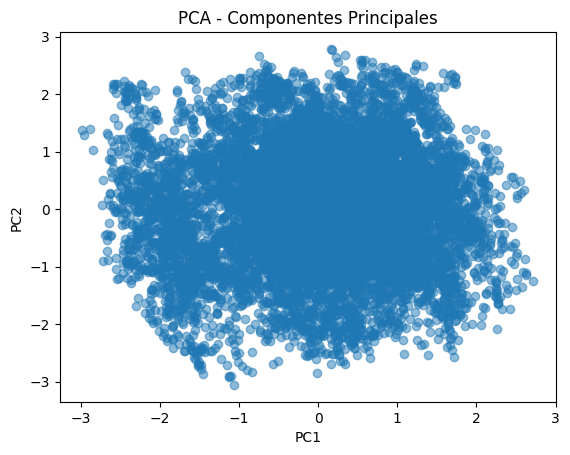

In [22]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

X_scaled = StandardScaler().fit_transform(X.fillna(0))
pca = PCA(n_components=2)
components = pca.fit_transform(X_scaled)

df['PC1'] = components[:, 0]
df['PC2'] = components[:, 1]

plt.scatter(df['PC1'], df['PC2'], alpha=0.5)
plt.title('PCA - Componentes Principales')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.show()


In [ ]:
df.to_csv("tipvos_transformado.csv", index=False)